В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
# from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
car_df = pd.read_csv(f'data/cars.csv')
car_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [3]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [4]:
car_df.shape

(100, 13)

In [5]:
car_df.dtypes

Car_ID                int64
Brand                object
Model                object
Year                  int64
Kilometers_Driven     int64
Fuel_Type            object
Transmission         object
Owner_Type           object
Mileage               int64
Engine                int64
Power                 int64
Seats                 int64
Price                 int64
dtype: object

In [6]:
car_df['Car_ID'] = car_df['Car_ID'].astype('string')

In [7]:
car_df.dtypes

Car_ID               string[python]
Brand                        object
Model                        object
Year                          int64
Kilometers_Driven             int64
Fuel_Type                    object
Transmission                 object
Owner_Type                   object
Mileage                       int64
Engine                        int64
Power                         int64
Seats                         int64
Price                         int64
dtype: object

In [8]:
category_car_df = car_df.select_dtypes(include = "object")

In [9]:
category_car_df.columns

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')

In [10]:
len(category_car_df.columns)

5

In [11]:
def unique_category(dataset, column):
    col = dataset[column]
    return {
        "column_name": col.name,
        "values": col.unique().tolist(),
        "values_amount": col.nunique(),
        "coulmn string type": type(col.loc[0])}

In [12]:
unique_category(category_car_df, 'Brand')

{'column_name': 'Brand',
 'values': ['Toyota',
  'Honda',
  'Ford',
  'Maruti',
  'Hyundai',
  'Tata',
  'Mahindra',
  'Volkswagen',
  'Audi',
  'BMW',
  'Mercedes'],
 'values_amount': 11,
 'coulmn string type': str}

In [13]:
unique_category(category_car_df, 'Model')

{'column_name': 'Model',
 'values': ['Corolla',
  'Civic',
  'Mustang',
  'Swift',
  'Sonata',
  'Nexon',
  'Scorpio',
  'Polo',
  'A4',
  'X1',
  'C-Class',
  'Endeavour',
  'Creta',
  'Harrier',
  'Ertiga',
  'City',
  'Tiguan',
  'Q3',
  '5 Series',
  'GLC',
  'Innova',
  'Figo',
  'Verna',
  'Altroz',
  'Thar',
  'Passat',
  'A6',
  'X3',
  'E-Class',
  'Fortuner',
  'Aspire',
  'Elantra',
  'Safari',
  'Vitara',
  'WR-V',
  'Ameo',
  'A3',
  '7 Series',
  'GLE',
  'Yaris',
  'Ranger',
  'Santro',
  'Tigor',
  'S-Cross',
  'BR-V',
  'T-Roc',
  'Q7',
  'X5',
  'GLA',
  'Camry',
  'Venue',
  'Tiago',
  'XUV300',
  'Vento',
  'A5',
  '3 Series',
  'Innova Crysta',
  'EcoSport'],
 'values_amount': 58,
 'coulmn string type': str}

In [14]:
unique_category(category_car_df, 'Fuel_Type')

{'column_name': 'Fuel_Type',
 'values': ['Petrol', 'Diesel'],
 'values_amount': 2,
 'coulmn string type': str}

In [15]:
unique_category(category_car_df, 'Transmission')

{'column_name': 'Transmission',
 'values': ['Manual', 'Automatic'],
 'values_amount': 2,
 'coulmn string type': str}

In [16]:
unique_category(category_car_df, 'Owner_Type')

{'column_name': 'Owner_Type',
 'values': ['First', 'Second', 'Third'],
 'values_amount': 3,
 'coulmn string type': str}

In [17]:
number_car_df = car_df.select_dtypes(include="number")

In [18]:
number_car_df.columns

Index(['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='object')

In [19]:
len(number_car_df.columns)

7

In [20]:
car_df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,2018.39000,28150.000000,17.210000,1855.230000,158.130000,5.230000,1.574000e+06
std,1.17116,9121.375716,3.309902,631.311475,76.968137,0.750151,1.000265e+06
min,2016.00000,10000.000000,10.000000,999.000000,68.000000,4.000000,4.500000e+05
25%,2017.75000,22000.000000,15.000000,1462.000000,103.000000,5.000000,7.000000e+05
50%,2018.00000,27000.000000,17.000000,1774.000000,148.000000,5.000000,1.300000e+06
75%,2019.00000,32000.000000,19.000000,2143.000000,187.000000,5.000000,2.500000e+06
max,2021.00000,60000.000000,25.000000,4951.000000,396.000000,7.000000,4.000000e+06


В наборі даних 7 числових/ int (було 8, але я перетворила CAR_ID на string) і 5 категоріальних колонок з них:
- 2 бінарні (Fuel_Type, Transmission)
- 2 мультикатегоріальних (Brand - 11 значень і Model 58 значень)
- 1 колонка, в якій можна встановити відношення порядку (Owner_type).

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [21]:
car_df.columns

Index(['Car_ID', 'Brand', 'Model', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price'],
      dtype='object')

In [42]:
inputs, targets = car_df[['Car_ID', 'Brand', 'Model', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']], car_df['Price']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.2, random_state=12)

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [44]:
X_train.Fuel_Type.value_counts()

Fuel_Type
Petrol    41
Diesel    39
Name: count, dtype: int64

In [45]:
X_test.Fuel_Type.value_counts()

Fuel_Type
Petrol    11
Diesel     9
Name: count, dtype: int64

In [46]:
binary_codes_fuel = {'Diesel': 0, 'Petrol': 1}
X_train['Fuel_Type_Code'] = X_train.Fuel_Type.map(binary_codes_fuel)
X_test['Fuel_Type_Code'] = X_test.Fuel_Type.map(binary_codes_fuel)

In [47]:
X_train.Fuel_Type_Code.value_counts()

Fuel_Type_Code
1    41
0    39
Name: count, dtype: int64

In [48]:
X_test.Fuel_Type_Code.value_counts()

Fuel_Type_Code
1    11
0     9
Name: count, dtype: int64

In [49]:
X_train.Transmission.value_counts()

Transmission
Automatic    49
Manual       31
Name: count, dtype: int64

In [50]:
X_test.Transmission.value_counts()

Transmission
Manual       12
Automatic     8
Name: count, dtype: int64

In [51]:
binary_codes_trans = {'Manual': 0, 'Automatic': 1}
X_train['Transmission_Code'] = X_train.Transmission.map(binary_codes_trans)
X_test['Transmission_Code'] = X_test.Transmission.map(binary_codes_trans)

In [52]:
X_train.Transmission_Code.value_counts()

Transmission_Code
1    49
0    31
Name: count, dtype: int64

In [53]:
X_test.Transmission_Code.value_counts()

Transmission_Code
0    12
1     8
Name: count, dtype: int64

In [54]:
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])
enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [55]:
one_hot_train = enc.transform(X_train[['Brand']]).toarray()
one_hot_train

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.

In [56]:
one_hot_test = enc.transform(X_test[['Brand']]).toarray()
one_hot_test

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.

In [57]:
enc.categories_[0]

array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
       'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)

In [58]:
X_train[enc.categories_[0]] = one_hot_train

In [59]:
X_test[enc.categories_[0]] = one_hot_test

In [60]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

In [61]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

Очікуваний результат після трансформацій:

In [ ]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [62]:
number_train_car_df = pd.concat([X_train.select_dtypes(include="number"), y_train], axis=1)

In [63]:
corr_1 = number_train_car_df.corr()

In [64]:
corr_1

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes,Price
Year,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499,-0.233769
Kilometers_Driven,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772,-0.083951
Mileage,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624,-0.638404
Engine,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106,0.710561
Power,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309,0.849137
Seats,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849,0.000979
Fuel_Type_Code,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.281122,-0.110782
Transmission_Code,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.005886,0.680731
Audi,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925,0.328858
BMW,0.202517,-0.247042,-0.134105,0.287119,0.372652,-0.108079,-0.048475,0.283188,-0.118678,1.000000,-0.126761,-0.091928,-0.101380,-0.081680,-0.091928,-0.126761,-0.134568,-0.118678,-0.110250,0.009076,0.477522


In [65]:
corr_1[(corr_1.abs() > 0.5) & (corr_1.abs() < 1)].unstack().sort_values(ascending=False).head(20)

Power              Price                0.849137
Price              Power                0.849137
Power              Engine               0.801638
Engine             Power                0.801638
                   Price                0.710561
Price              Engine               0.710561
Transmission_Code  Price                0.680731
Price              Transmission_Code    0.680731
Transmission_Code  Power                0.586910
Power              Transmission_Code    0.586910
Mileage            Price               -0.638404
Price              Mileage             -0.638404
Power              Mileage             -0.684705
Mileage            Power               -0.684705
Kilometers_Driven  Year                -0.708525
Year               Kilometers_Driven   -0.708525
Mileage            Engine              -0.710516
Engine             Mileage             -0.710516
Year               Year                      NaN
                   Mileage                   NaN
dtype: float64

**Висновок**
- Найкраще з ціною позитивно корилюють потужність автомобіля, об'єм двигуна і тип трансмісії автомобіля (0.85, 0.71 і 0.68), потужність автомобіля і об'єм двигуна одночасно корилюють між собою на рівні 0.8, потужність і тип трансмісії автомобіля - корилюють між собою на рівні 0.59. Можна було б протестувати як змінюється якість моделі при викорстанні тільки однієї з цих ознак, враховуючи їхню взаємну позитивну кориляцію, яку можна співставити з подібною позитивною кориляцією з таргетом.
- Паливна ефективність автомобіля має помірну негативну кореляцію з ціною - "-0.64". Одночасно ця ознака негативно корелює з потужністю автомобіля "-0.69" і об'ємом двигуна "-0.71".

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [66]:
X_train = X_train.select_dtypes(include='number')

In [67]:
X_test = X_test.select_dtypes(include='number')

In [68]:
linear_model = LinearRegression().fit(X_train, y_train)

In [69]:
predictions_train = linear_model.predict(X_train)

In [70]:
predictions_test = linear_model.predict(X_test)

In [71]:
loss_train = np.sqrt(mean_squared_error(y_train, predictions_train))
print(loss_train)

210342.8016204644


In [72]:
loss_test = np.sqrt(mean_squared_error(y_test, predictions_test))
print(loss_test)

259601.26542723566


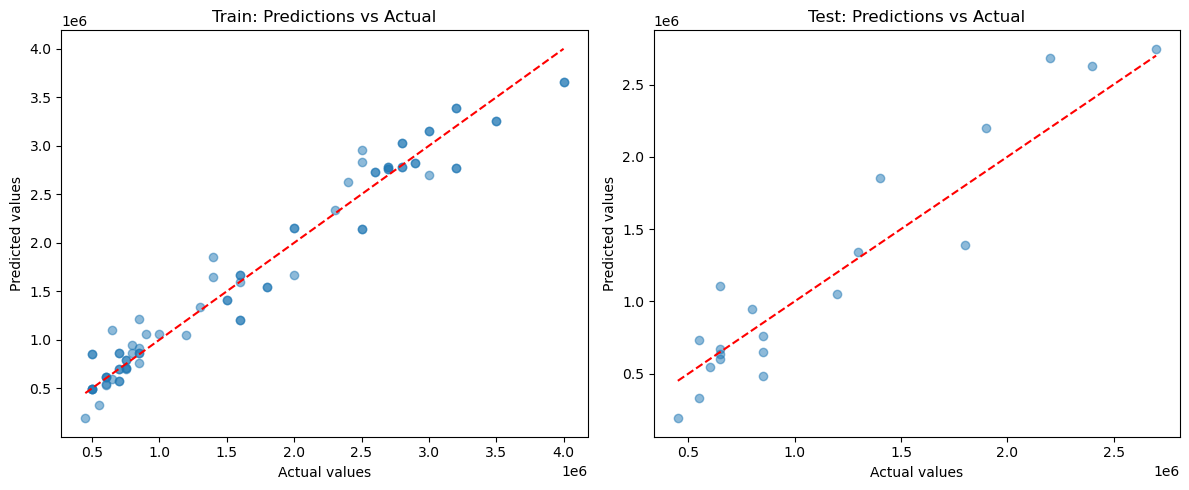

In [73]:
plt.figure(figsize=(12, 5))

# --- TRAIN ---
plt.subplot(1, 2, 1)
plt.scatter(y_train, predictions_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linestyle='--')
plt.title("Train: Predictions vs Actual")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")

# --- TEST ---
plt.subplot(1, 2, 2)
plt.scatter(y_test, predictions_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.title("Test: Predictions vs Actual")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")

plt.tight_layout()
plt.show();

In [74]:
linear_model.coef_, linear_model.intercept_, linear_model.feature_names_in_

(array([-1.03539595e+04, -1.08744370e+01, -3.86667124e+04, -3.75858737e+01,
         6.14075646e+03, -2.35301226e+03, -3.70607514e+05,  2.36367638e+05,
         7.58803045e+05,  7.30326849e+05, -3.05098169e+05, -1.89002506e+05,
        -5.05043272e+05, -5.74912608e+05, -3.94216231e+05,  7.33974724e+05,
        -1.26504171e+05,  1.30457503e+05, -2.58785164e+05,  6.62783066e+04]),
 np.float64(22529791.832420513),
 array(['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
        'Fuel_Type_Code', 'Transmission_Code', 'Audi', 'BMW', 'Ford',
        'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata',
        'Toyota', 'Volkswagen', 'Owner_Type_Codes'], dtype=object))

In [75]:
X_train.head()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


**Висновок**
- Точки лежать доволі близько до червоної лінії на тренувальних даних і трохи більш розкидані, але немає сильних “хмар” вище чи нижче лінії для тестувальних даних. Вважаю, що з першого погляду модель виглядає задовільною

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [76]:
from sklearn.preprocessing import StandardScaler

In [77]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [78]:
scaled_train_inputs = scaler.transform(X_train)
scaled_test_inputs = scaler.transform(X_test)

In [79]:
X_train_scaled_df = pd.DataFrame(
    scaled_train_inputs,
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled_df = pd.DataFrame(
    scaled_test_inputs,
    columns=X_test.columns,
    index=X_test.index
)

In [80]:
linear_model_scaled = LinearRegression().fit(X_train_scaled_df, y_train)

In [81]:
scaled_predictions_train = linear_model_scaled.predict(X_train_scaled_df)

In [82]:
scaled_predictions_test = linear_model_scaled.predict(X_test_scaled_df)

In [83]:
coef_table = pd.DataFrame({
    "feature": linear_model_scaled.feature_names_in_,
    "coef": linear_model_scaled.coef_,
    "abs_coef": np.abs(linear_model_scaled.coef_)
})

coef_table.sort_values("abs_coef", ascending=False, inplace=True)

coef_table

,feature,coef,abs_coef
4,Power,500000.506765,500000.506765
15,Mercedes,209257.737636,209257.737636
9,BMW,208105.079738,208105.079738
8,Audi,206123.092108,206123.092108
6,Fuel_Type_Code,-185245.840763,185245.840763
12,Hyundai,-151916.052473,151916.052473
13,Mahindra,-140931.632855,140931.632855
2,Mileage,-131884.633123,131884.633123
10,Ford,-119069.155830,119069.155830
7,Transmission_Code,115153.439599,115153.439599


**Висновок**
- Рівень потужності автомобіля є ознакою з найбільш вагомим позитивним коефіцієнтом для нашої моделі, що виглядає доволі логічно: ціна зростає зі зростанням потужності автомобіля, що цінно що це характеристика за якою можна описати будь-який автомобіль, вимірна, що є доброю основою для моделі, ризики тільки в відсутності цієї ознаки на вході, адже це сильно погіршить якість моделі.
- Приналежність до однієї з наступних трьох марок: Mercedes, BMW і Audi є ознакою з вагомим позитивним коефіцієнтом, що виглядає доволі логічно: ціна очікувано буде вищою для більш дорогих марок автомобілів на вторинному ринку Індії (проконсультувалась з чатом gpt:);
- Тип палива - ознака з найбільш вагомим негативним коефіцієнтом. Виглядає логічно, вартість типу палива сильно впливає на майбутнє обслуговування автомобіля, що мабуть має не останнє значення для осіб, які купують авто на вторинному ринку.
- Приналежність до однієї з наступних марок: Hyundai, Mahindra, Maruti і Ford є ознакою з вагомим негативними коефіцієнтом, що виглядає доволі логічно: ціна очікувано буде нищою для більш дешевих марок автомобілів на вторинному ринку Індії (проконсультувалась з чатом gpt:);
- Паливна ефективність і величина пробігу автомобіля - вагомі ознаки з негативними коефіцієнтами. Виглядає також логічно, чим більше палива споживає автомобіль і чим довше він був в обігу, тим нижче оцікувано його ціна.
- Тип трансмісіЇ - є ознакою з вагомим позитивним коефіцієнтом.
- Решта марок автомобілів так само позитивно чи негативно впливають на ціну, але цей вплив вже менш виражений, можливо їх додавання в модель створює зайвий шум;
- К-ть попередніх власників є слабо вираженою ознакою з позитивним коефіцієнтом, тоді як об'єм двигуна і рік автомобіля є  слабо вираженими ознаками з негативним коефіцієнтом. К-ть сидінь настільки низько виражений вплив в порівнянні з вагою інших коефіцієнтів, що мабуть доречно також усунути.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [84]:
X = sm.add_constant(X_train_scaled_df)
model = sm.OLS(y_train,X)
results = model.fit()
results.params

const                1.680000e+06
Year                -1.160426e+04
Kilometers_Driven   -9.971396e+04
Mileage             -1.318846e+05
Engine              -2.468308e+04
Power                5.000005e+05
Seats               -1.744049e+03
Fuel_Type_Code      -1.852458e+05
Transmission_Code    1.151534e+05
Audi                 2.061231e+05
BMW                  2.081051e+05
Ford                -1.190692e+05
Honda               -6.311234e+04
Hyundai             -1.519161e+05
Mahindra            -1.409316e+05
Maruti              -1.127867e+05
Mercedes             2.092577e+05
Tata                -6.555849e+04
Toyota               1.761943e+04
Volkswagen          -9.339136e+04
Owner_Type_Codes     4.333507e+04
dtype: float64

In [85]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     73.14
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.34e-34
Time:                        19:36:12   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2228.
Df Residuals:                      60   BIC:                             2276.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.72e+0

In [86]:
params = results.params
pvalues = results.pvalues

significant = pd.DataFrame({
    "coef": params,
    "p_value": pvalues
})

significant = significant[pvalues < 0.05].sort_values("p_value")

significant

,coef,p_value
const,1.680000e+06,4.664110e-56
Power,5.000005e+05,3.439085e-09
Audi,2.061231e+05,4.549697e-09
Mercedes,2.092577e+05,5.705474e-09
BMW,2.081051e+05,1.263795e-08
Hyundai,-1.519161e+05,1.789695e-06
Mahindra,-1.409316e+05,1.149900e-05
Fuel_Type_Code,-1.852458e+05,1.024429e-04
Maruti,-1.127867e+05,2.230838e-04
Ford,-1.190692e+05,6.379237e-04


Вищевиведені ознаки є стат. значимі на рівні 0.05.

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [87]:
significant_features = [col for col in significant.index if col != "const"]

In [88]:
X_train_sig = X_train_scaled_df[significant_features]
X_test_sig = X_test_scaled_df[significant_features]

In [89]:
X_1 = sm.add_constant(X_train_sig)
model_sig = sm.OLS(y_train,X_1)
results_sig = model_sig.fit()
results_sig.params

const                1.680000e+06
Power                4.556152e+05
Audi                 2.496895e+05
Mercedes             2.767291e+05
BMW                  2.949781e+05
Hyundai             -1.027479e+05
Mahindra            -8.538214e+04
Fuel_Type_Code      -1.337141e+05
Maruti              -5.117881e+04
Ford                -4.855211e+04
Volkswagen          -2.375201e+04
Transmission_Code    1.310778e+05
Mileage             -1.430094e+05
dtype: float64

In [90]:
print(results_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.12e-39
Time:                        19:38:41   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

**Висновок**
Модель зі всіма параметрами:
R-squared: 0.959
Adj. R-squared: 0.946.
Модель з параметрами зі стат. значимістю 0.05:
R-squared: 0.951
Adj. R-squared 0.943.
Якщо оцінювати, тільки за цими показниками, то усування решти ознак з моделі не сильно вплинуло на якість моделі. Особливо це видно по Adj. R-squared (чутливий до к-ті ознак) який майже не змінився.

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 7 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 7? Яку модель з останніх 3х завдань ви б лишили для використання?

In [91]:
params = results.params
pvalues = results.pvalues

significant_1 = pd.DataFrame({
    "coef": params,
    "p_value": pvalues
})

significant_1 = significant_1[pvalues < 0.25].sort_values("p_value")

significant_1

,coef,p_value
const,1.680000e+06,4.664110e-56
Power,5.000005e+05,3.439085e-09
Audi,2.061231e+05,4.549697e-09
Mercedes,2.092577e+05,5.705474e-09
BMW,2.081051e+05,1.263795e-08
Hyundai,-1.519161e+05,1.789695e-06
Mahindra,-1.409316e+05,1.149900e-05
Fuel_Type_Code,-1.852458e+05,1.024429e-04
Maruti,-1.127867e+05,2.230838e-04
Ford,-1.190692e+05,6.379237e-04


In [92]:
significant_features_1 = [col for col in significant_1.index if col != "const"]

In [93]:
X_train_sig_2 = X_train_scaled_df[significant_features_1]
X_test_sig_2 = X_test_scaled_df[significant_features_1]

In [94]:
X_2 = sm.add_constant(X_train_sig_2)
model_sig_2 = sm.OLS(y_train,X_2)
results_sig_2 = model_sig_2.fit()
results_sig_2.params

const                1.680000e+06
Power                4.666618e+05
Audi                 1.949556e+05
Mercedes             2.048056e+05
BMW                  2.092733e+05
Hyundai             -1.518157e+05
Mahindra            -1.444257e+05
Fuel_Type_Code      -1.629442e+05
Maruti              -1.159256e+05
Ford                -1.139975e+05
Volkswagen          -9.072986e+04
Transmission_Code    1.175415e+05
Mileage             -1.213232e+05
Honda               -7.974914e+04
Kilometers_Driven   -7.887396e+04
Tata                -9.700832e+04
dtype: float64

In [95]:
print(results_sig_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.85e-38
Time:                        19:49:02   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.65e+0

**Висновок**
Модель зі всіма параметрами:
R-squared: 0.959
Adj. R-squared: 0.946.
Модель з параметрами зі стат. значимістю 0.25:
R-squared: 0.958
Adj. R-squared 0.948.
Цього разу R-squared майже однакові, і при цьому з натяжкою можна сказати, що Adj. R-squared трошки покращився, але статестично все ж вважаю незначно. Тож якщо оцінювати, тільки за цими показниками, то в третій моделі нас вдалось досягнути найкращого балансу ознак.
Хоча в цілому така к-ть ознак три нашому обсягу екземплярів є завеликою.

In [96]:
stability = pd.DataFrame({
    "M1": results.params,
    "M2": results_sig.params,
    "M3": results_sig_2.params
})

In [97]:
stability

,M1,M2,M3
Audi,2.061231e+05,2.496895e+05,1.949556e+05
BMW,2.081051e+05,2.949781e+05,2.092733e+05
Engine,-2.468308e+04,NaN,NaN
Ford,-1.190692e+05,-4.855211e+04,-1.139975e+05
Fuel_Type_Code,-1.852458e+05,-1.337141e+05,-1.629442e+05
Honda,-6.311234e+04,NaN,-7.974914e+04
Hyundai,-1.519161e+05,-1.027479e+05,-1.518157e+05
Kilometers_Driven,-9.971396e+04,NaN,-7.887396e+04
Mahindra,-1.409316e+05,-8.538214e+04,-1.444257e+05
Maruti,-1.127867e+05,-5.117881e+04,-1.159256e+05


**Висновок**
Аналіз коефіцієнтів стабільності демонструє, що показники потужності, типу трансмісії/ палива, паливноЇ ефективності автомобіля та преміальних брендів (Audi, BMW, Mercedes) залишаються дуже стабільними для всіх специфікацій моделі, що підтверджує їхню сильну та незалежну прогностичну цінність. Натомість, для решти ознак коефіцієнти значно змінюються, що може вказувати на мультиколінеарність або слабку пояснювальну силу. Остаточна модель зберігає лише стабільні, економічно значущі предиктори.

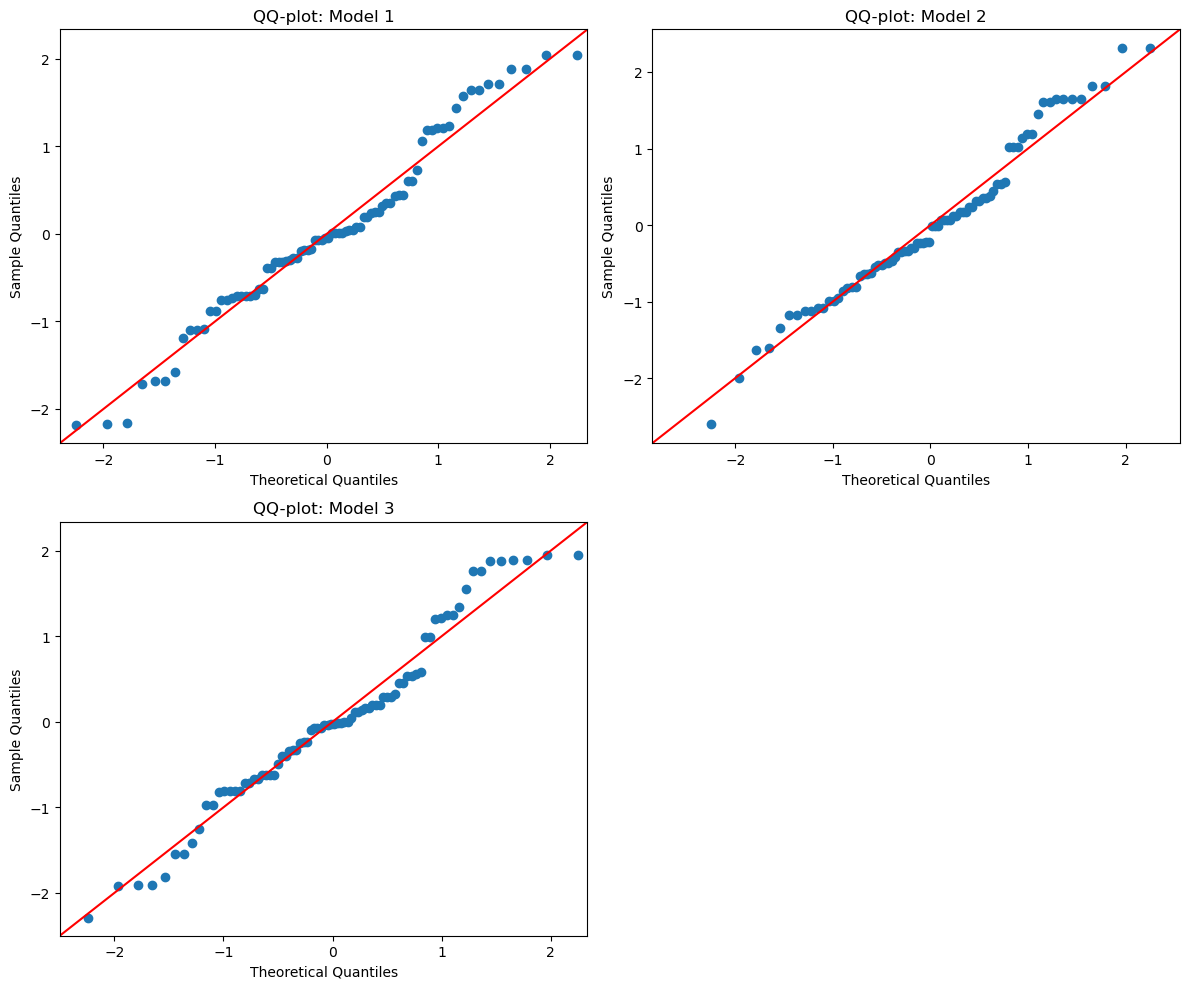

In [98]:
all_models = [results, results_sig, results_sig_2]
titles = ["Model 1", "Model 2", "Model 3"]

plt.figure(figsize=(12, 10))

for i, (model, title) in enumerate(zip(all_models, titles), 1):
    plt.subplot(2, 2, i)
    sm.qqplot(model.resid, line="45", fit=True, ax=plt.gca())
    plt.title(f"QQ-plot: {title}")

plt.tight_layout()
plt.show()

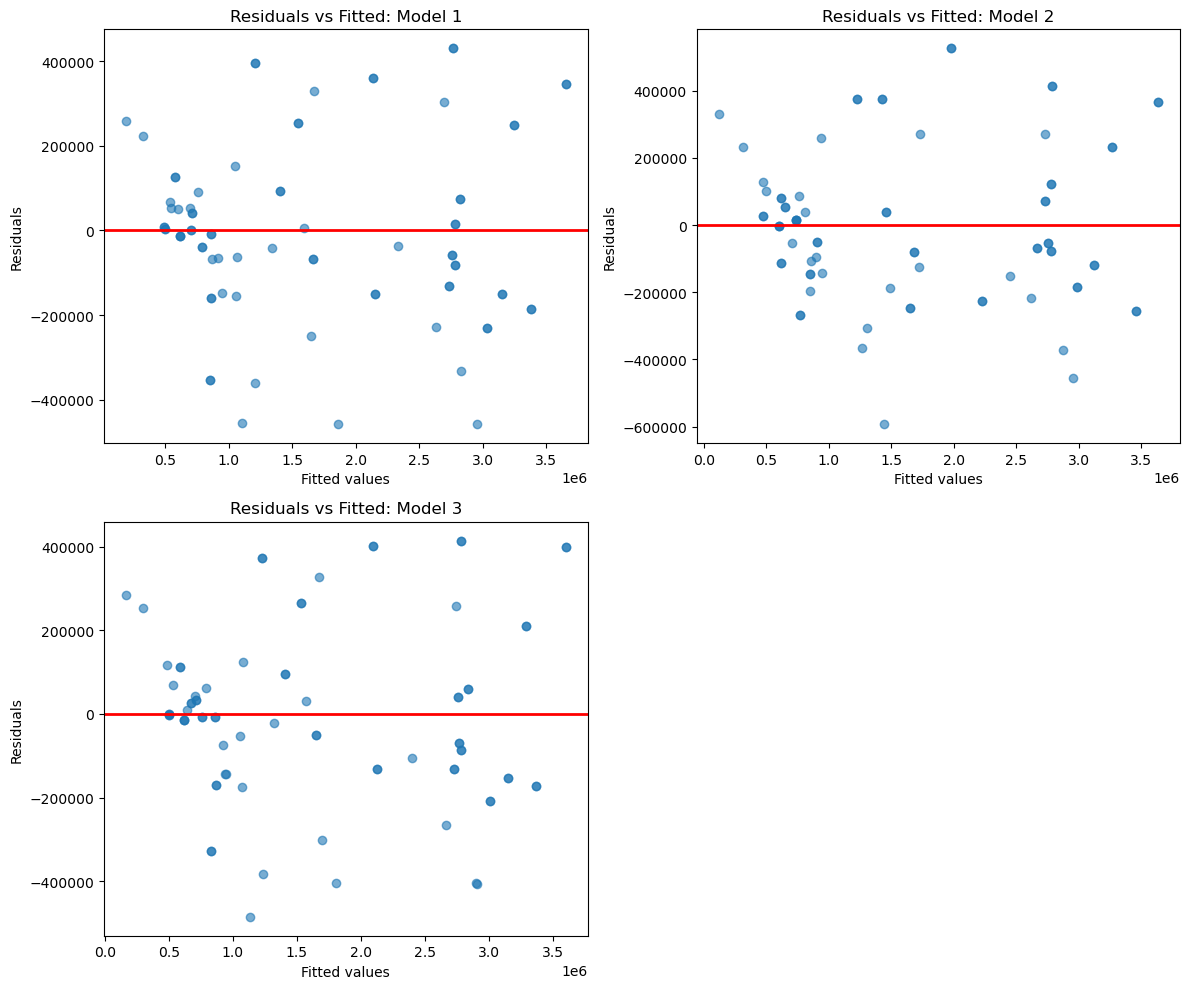

In [99]:
plt.figure(figsize=(12, 10))

for i, (model, title) in enumerate(zip(all_models, titles), 1):
    fitted = model.fittedvalues
    residuals = model.resid
    
    plt.subplot(2, 2, i)
    plt.scatter(fitted, residuals, alpha=0.6)
    plt.axhline(0, color='red', linewidth=2)
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted: {title}")

plt.tight_layout()
plt.show()

**Висновок**
Model 3 включає в себе найбільш стабільні коефіцієнти і має залишки, які не показують систематичних помилок. Я б обрала її для використання, але враховуюючи к-ть ознак у співвідношенні до кількості екземплярів, я б старалась отримати більше даних для доопрацювання/тренування моделі.